# gVXR polychromatic package radiography

This reduced Colab smoke test compares unfiltered and Al/Cu-filtered 160 kV spectra on a deterministic SiO₂ cuboid. It validates spectral simulation and records reproducibility metadata; it is not a calibrated scanner model.

**Version check:** this maintained notebook uses an explicit Kramers spectrum, `addEnergyBinToSpectrumPerPixelAtSDD()`, and a single SiO₂ cuboid. If a Colab tab uses `setVoltage()` directly in the projection context, shows a multi-material phantom, or contains extra diagnostic cells, it is an older cached notebook. Close it and reopen the `main`-branch Colab badge from the repository README.

In [1]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !apt-get update -qq
    !apt-get install -y -qq libnvidia-gl-580 libxcb-res0 libxcb-ewmh2 libxcb-composite0 libxcb-cursor0 libxcb-xinerama0 libxcb-keysyms1 libxcb-icccm4 libxcb-xkb1

repo = Path('/content/xsim-chip')
if repo.exists():
    !git -C {repo} checkout -q main
    !git -C {repo} pull --ff-only -q origin main
else:
    !git clone -q https://github.com/yuweimin2077-hub/xsim-chip.git {repo}
%cd /content/xsim-chip
%pip install -q -e '.[spectral]'
!git rev-parse --short HEAD

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libnvidia-cfg1-580:amd64.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../00-libnvidia-cfg1-580_580.178.04-1ubuntu1_amd64.deb ...
Unpacking libnvidia-cfg1-580:amd64 (580.178.04-1ubuntu1) ...
Selecting previously unselected package libnvidia-decode-580:amd64.
Preparing to unpack .../01-libnvidia-decode-580_580.178.04-1ubuntu1_amd64.deb ...
Unpacking libnvidia-decode-580:amd64 (580.178.04-1ubuntu1) ...
Selecting previously unselected package libnvidia-gpucomp-580:amd64.
Preparing to unpack .../02-libnvidia-gpucomp-580_580.178.04-1ubuntu1_amd64.deb ...
Unpacking libnvidia-gpucomp-580:amd64 (580.178.04-1ubuntu1) ...
Selecting previously unselected package nvidia-persistenced.
Preparing to unpack .../03-nvidia-persist

In [2]:
import json
import time
import matplotlib.pyplot as plt
import numpy as np
from gvxrPython3 import gvxr
from xsim_chip_analysis import (
    ConeBeamConfig, SimulationConfig, SpectrumConfig, build_run_manifest,
    normalise_energy_image, summarise_spectrum,
)

spectrum = SpectrumConfig()
geometry = ConeBeamConfig()
print('Core gVXR:', gvxr.getVersionOfCoreGVXR())
print('SimpleGVXR:', gvxr.getVersionOfSimpleGVXR())
print('Spectrum config:', json.dumps(spectrum.to_manifest(), indent=2))
print('Cone-beam config:', json.dumps(geometry.to_manifest(), indent=2))

Core gVXR: gVirtualXRay core library (gvxr) 2.1.0 (2026-06-09T15:18:01) [Compiler: GNU g++] on Linux
SimpleGVXR: SimpleGVXR 2.1.0 (2026-06-09T15:18:02) [Compiler: GNU g++] on Linux
Spectrum config: {
  "tube_voltage_kv": 160.0,
  "energy_bin_size_kev": 4.0,
  "exposure_mas": 1.0,
  "filters_mm": [
    {
      "element": "Al",
      "thickness_mm": 0.5
    },
    {
      "element": "Cu",
      "thickness_mm": 1.0
    }
  ]
}
Cone-beam config: {
  "source_position_mm": [
    -200.0,
    0.0,
    0.0
  ],
  "detector_position_mm": [
    400.0,
    0.0,
    0.0
  ],
  "detector_pixels_xy": [
    192,
    128
  ],
  "detector_pixel_size_mm": [
    0.16,
    0.16
  ],
  "magnification": 3.0,
  "object_pixel_size_mm": [
    0.05333333333333334,
    0.05333333333333334
  ]
}


## Stable SiO₂ smoke-test phantom

The geometry uses one built-in SiO₂ cuboid to keep the Colab gVXR smoke test stable while preserving cone-beam magnification. Multi-material package geometry remains a follow-up task.

In [3]:
started = time.perf_counter()
energy_unfiltered = np.arange(
    spectrum.energy_bin_size_kev, spectrum.tube_voltage_kv, spectrum.energy_bin_size_kev,
    dtype=np.float64,
)
# Kramers-law photon continuum: N(E) is proportional to E_max / E - 1.
counts_unfiltered = spectrum.tube_voltage_kv / energy_unfiltered - 1.0
counts_unfiltered *= 100_000.0 * spectrum.exposure_mas / counts_unfiltered.sum()

filter_atomic_number = {'Al': 13, 'Cu': 29}
filter_density_g_cm3 = {'Al': 2.70, 'Cu': 8.96}
filter_optical_depth = np.zeros_like(energy_unfiltered)
for element, thickness_mm in spectrum.filters_mm:
    mass_attenuation = np.asarray([
        gvxr.getMassAttenuationFromElement(filter_atomic_number[element], float(energy), 'keV')
        for energy in energy_unfiltered
    ])
    filter_optical_depth += mass_attenuation * filter_density_g_cm3[element] * thickness_mm / 10.0
energy_filtered = energy_unfiltered.copy()
counts_filtered = counts_unfiltered * np.exp(-filter_optical_depth)
print('Explicit spectra prepared:', len(energy_unfiltered), 'energy bins')

Explicit spectra prepared: 39 energy bins


## Unfiltered versus filtered polychromatic exposure

A deterministic Kramers-law continuum represents the 160 kV tube spectrum. gVXR mass attenuation coefficients apply 0.5 mm Al and 1.0 mm Cu filtration. The bins are then loaded explicitly before detector creation; this avoids a gVXR 2.1/Colab failure in the automatic `setVoltage()` projection path.

In [4]:
def compute_validated_transmission(label, energies_kev, photon_counts):
    gvxr.createOpenGLContext()
    try:
        gvxr.setSourcePosition(*geometry.source_position_mm, 'mm')
        gvxr.usePointSource()
        for energy_kev, photon_count in zip(energies_kev, photon_counts):
            gvxr.addEnergyBinToSpectrumPerPixelAtSDD(
                float(energy_kev), 'keV', float(photon_count),
            )
        gvxr.setDetectorPosition(*geometry.detector_position_mm, 'mm')
        gvxr.setDetectorUpVector(0, 0, -1)
        gvxr.setDetectorNumberOfPixels(*geometry.detector_pixels_xy)
        gvxr.setDetectorPixelSize(*geometry.detector_pixel_size_mm, 'mm')
        gvxr.makeCuboid('SiO2_core', 0.8, 8.0, 5.0, 'mm')
        gvxr.addPolygonMeshAsOuterSurface('SiO2_core')
        gvxr.setCompound('SiO2_core', 'SiO2')
        gvxr.setDensity('SiO2_core', 2.20, 'g/cm3')

        raw = np.asarray(gvxr.computeXRayImage())
        expected_shape = tuple(reversed(geometry.detector_pixels_xy))
        if raw.shape != expected_shape:
            raise RuntimeError(
                f'{label} gVXR projection has shape {raw.shape}, expected {expected_shape}. '
                'Reconnect the runtime and reopen the current main-branch notebook.'
            )
        incident_energy = gvxr.getTotalEnergyWithDetectorResponse()
        runtime = {
            'core': gvxr.getVersionOfCoreGVXR(),
            'simple': gvxr.getVersionOfSimpleGVXR(),
            'opengl_vendor': gvxr.getOpenGlVendor(),
            'opengl_renderer': gvxr.getOpenGlRenderer(),
            'opengl_version': gvxr.getOpenGlVersion(),
        }
        return normalise_energy_image(raw, incident_energy), runtime
    finally:
        gvxr.terminate()

image_unfiltered, gvxr_runtime = compute_validated_transmission(
    'Unfiltered', energy_unfiltered, counts_unfiltered,
)
summary_unfiltered = summarise_spectrum(energy_unfiltered, counts_unfiltered)

image_filtered, _ = compute_validated_transmission(
    'Filtered', energy_filtered, counts_filtered,
)
summary_filtered = summarise_spectrum(energy_filtered, counts_filtered)

object_mask = np.minimum(image_unfiltered, image_filtered) < 0.999
if not object_mask.any():
    raise RuntimeError('The projection is valid but the SiO2 object is outside the detector field of view')
metrics = {
    'mean_energy_shift_kev': summary_filtered['mean_energy_kev'] - summary_unfiltered['mean_energy_kev'],
    'mean_unfiltered_transmission': float(image_unfiltered[object_mask].mean()),
    'mean_filtered_transmission': float(image_filtered[object_mask].mean()),
    'mean_absolute_transmission_change': float(np.abs(image_filtered - image_unfiltered)[object_mask].mean()),
    'object_pixels': int(object_mask.sum()),
}
print('Unfiltered:', json.dumps(summary_unfiltered, indent=2))
print('Filtered:', json.dumps(summary_filtered, indent=2))
print('Comparison:', json.dumps(metrics, indent=2))

Unfiltered: {
  "bins": 39,
  "min_energy_kev": 4.0,
  "max_energy_kev": 156.0,
  "mean_energy_kev": 23.791055683473576,
  "peak_energy_kev": 4.0,
  "fraction_below_40_kev": 0.794245560617387
}
Filtered: {
  "bins": 39,
  "min_energy_kev": 4.0,
  "max_energy_kev": 156.0,
  "mean_energy_kev": 89.345339325609,
  "peak_energy_kev": 76.0,
  "fraction_below_40_kev": 0.0011952619701472208
}
Comparison: {
  "mean_energy_shift_kev": 65.55428364213543,
  "mean_unfiltered_transmission": 0.7672181725502014,
  "mean_filtered_transmission": 0.9679243564605713,
  "mean_absolute_transmission_change": 0.20070618391036987,
  "object_pixels": 14100
}


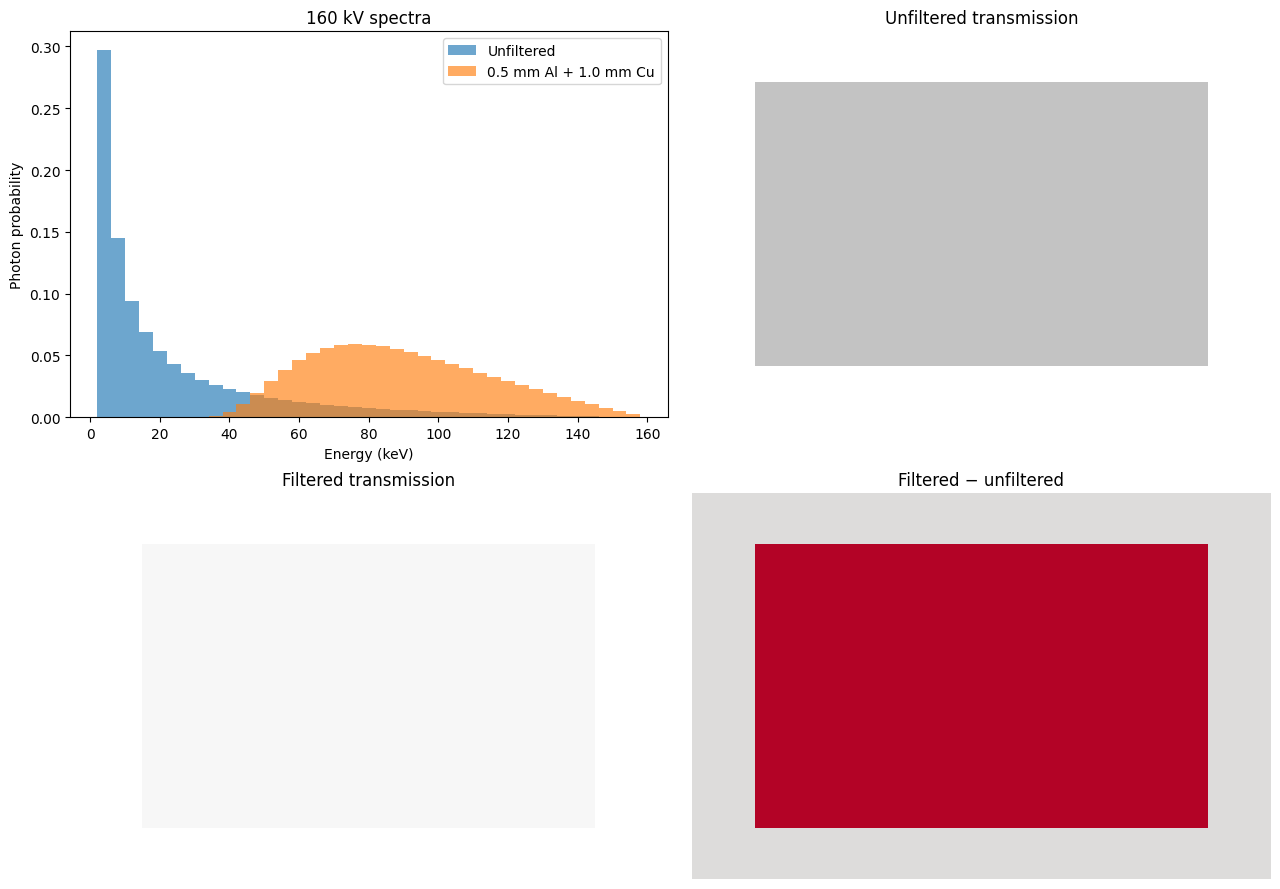

In [5]:
probability_unfiltered = counts_unfiltered / counts_unfiltered.sum()
probability_filtered = counts_filtered / counts_filtered.sum()
figure, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].bar(energy_unfiltered, probability_unfiltered, width=spectrum.energy_bin_size_kev, alpha=0.65, label='Unfiltered')
axes[0, 0].bar(energy_filtered, probability_filtered, width=spectrum.energy_bin_size_kev, alpha=0.65, label='0.5 mm Al + 1.0 mm Cu')
axes[0, 0].set(xlabel='Energy (keV)', ylabel='Photon probability', title='160 kV spectra')
axes[0, 0].legend()
axes[0, 1].imshow(image_unfiltered, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Unfiltered transmission')
axes[1, 0].imshow(image_filtered, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Filtered transmission')
difference = image_filtered - image_unfiltered
limit = max(float(np.abs(difference).max()), 1e-6)
axes[1, 1].imshow(difference, cmap='coolwarm', vmin=-limit, vmax=limit)
axes[1, 1].set_title('Filtered − unfiltered')
for ax in (axes[0, 1], axes[1, 0], axes[1, 1]): ax.axis('off')
plt.tight_layout()

## Save reproducibility artefacts

The compact arrays and manifest are written outside Git. The manifest distinguishes measured outputs from scanner assumptions and limitations.

In [6]:
elapsed = time.perf_counter() - started
output_dir = Path('/content/xsim_outputs/gvxr_spectral')
output_dir.mkdir(parents=True, exist_ok=True)
manifest = build_run_manifest(SimulationConfig.quick_colab(), elapsed_seconds=elapsed)
manifest['experiment'] = 'gvxr-polychromatic-radiography-v1'
manifest['spectrum'] = spectrum.to_manifest()
manifest['geometry'] = geometry.to_manifest()
manifest['spectrum_model'] = 'deterministic Kramers continuum with gVXR mass attenuation filtering'
manifest['gvxr_runtime'] = gvxr_runtime
manifest['result'] = {
    'unfiltered_spectrum': summary_unfiltered,
    'filtered_spectrum': summary_filtered,
    **metrics,
}
manifest['limitations'] = [
    'Compact cuboid phantom, not the full NIST STL package',
    'Ideal energy-integrating detector; no scatter or detector blur',
    'Kramers continuum is a deterministic smoke-test spectrum, not a calibrated tube spectrum',
    'Geometry, filtration, and exposure are simulation assumptions, not scanner calibration',
]
(output_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
np.savez_compressed(
    output_dir / 'spectral_radiography.npz',
    energy_unfiltered_kev=energy_unfiltered, counts_unfiltered=counts_unfiltered,
    energy_filtered_kev=energy_filtered, counts_filtered=counts_filtered,
    image_unfiltered=image_unfiltered, image_filtered=image_filtered,
)
figure.savefig(output_dir / 'spectral_comparison.png', dpi=160, bbox_inches='tight')
print(json.dumps(manifest, indent=2))
print('Saved to', output_dir)

{
  "schema_version": "1.0",
  "created_utc": "2026-09-08T23:59:27.592267+00:00",
  "config": {
    "profile": "quick-colab",
    "volume_shape_zyx": [
      129,
      129,
      129
    ],
    "detector_shape_rc": [
      129,
      192
    ],
    "projections": 180,
    "voxel_size_um": 16.0,
    "seed": 2060
  },
  "memory_estimate": {
    "label_volume_uint8_gib": 0.002,
    "working_volume_float32_gib": 0.008,
    "projection_stack_float32_gib": 0.0166,
    "projection_stack_uint16_gib": 0.0083,
    "reconstruction_float32_gib": 0.008,
    "declared_numpy_buffers_gib": 0.0429,
    "streamed_projection_floor_gib": 0.0263
  },
  "runtime": {
    "python": "3.13.15",
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
    "is_google_colab": true,
    "colab_release_tag": "release-colab-external-images_20260902-060045_RC00",
    "gpu": {
      "available": "true",
      "description": "Tesla T4, 580.82.07, 15360"
    },
    "elapsed_seconds": 2.2680893890000107
  },
  "packages":